# 05 Univariate Analysis

## Objective

Objective:
Perform univariate analysis to understand the distribution,
patterns, and characteristics of individual features.

This step helps in:
- Understanding data distribution
- Identifying skewness and outliers
- Detecting imbalance in categorical features
- Preparing for feature engineering and modeling


## Imports


In [20]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, TARGET_COLUMN
from src.data.data_loader import load_cleaned_data

sns.set_theme(style="whitegrid")


## Report Paths


In [21]:
REPORTS_DIR = project_root / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
TARGET_FIGURES_DIR = FIGURES_DIR / "target"
NUMERICAL_FIGURES_DIR = FIGURES_DIR / "numerical"
CATEGORICAL_FIGURES_DIR = FIGURES_DIR / "categorical"
TARGET_TABLES_DIR = TABLES_DIR / "target"
NUMERICAL_TABLES_DIR = TABLES_DIR / "numerical"
CATEGORICAL_TABLES_DIR = TABLES_DIR / "categorical"
EDA_REPORT_PATH = REPORTS_DIR / "eda_report.md"

for path in [
    TARGET_FIGURES_DIR,
    NUMERICAL_FIGURES_DIR,
    CATEGORICAL_FIGURES_DIR,
    TARGET_TABLES_DIR,
    NUMERICAL_TABLES_DIR,
    CATEGORICAL_TABLES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

{
    "reports_dir": REPORTS_DIR,
    "target_figures": TARGET_FIGURES_DIR,
    "numerical_figures": NUMERICAL_FIGURES_DIR,
    "categorical_figures": CATEGORICAL_FIGURES_DIR,
    "target_tables": TARGET_TABLES_DIR,
    "numerical_tables": NUMERICAL_TABLES_DIR,
    "categorical_tables": CATEGORICAL_TABLES_DIR,
    "eda_report": EDA_REPORT_PATH,
}


{'reports_dir': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports'),
 'target_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/target'),
 'numerical_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/numerical'),
 'categorical_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/categorical'),
 'target_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/target'),
 'numerical_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/numerical'),
 'categorical_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/categorical'),
 'eda_report': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/eda_report.md')}

## Load Data and Separate Column Types


In [22]:
df = load_cleaned_data()
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
target_column = TARGET_COLUMN
numerical_columns = [column for column in NUMERICAL_COLUMNS if column in df.columns]
categorical_columns = [column for column in CATEGORICAL_COLUMNS if column in df.columns]
binary_columns = [
    column
    for column in categorical_columns
    if df[column].dropna().nunique() == 2
]

column_groups = {
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
    "binary_columns": binary_columns,
    "target_column": target_column,
}

column_groups


{'numerical_columns': ['tenure', 'MonthlyCharges', 'TotalCharges'],
 'categorical_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 'binary_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'PaperlessBilling'],
 'target_column': 'Churn'}

## Target Column Analysis

Analyze the target column on its own to understand class counts, class percentages, and the degree of class imbalance before moving to feature-level analysis.


In [24]:
target_counts = df[target_column].value_counts().sort_index()
target_percentages = df[target_column].value_counts(normalize=True).sort_index().mul(100).round(2)

imbalance_ratio = round(target_counts.max() / target_counts.min(), 2)

if imbalance_ratio < 1.5:
    imbalance_level = "Low imbalance"
elif imbalance_ratio < 3:
    imbalance_level = "Moderate imbalance"
else:
    imbalance_level = "High imbalance"

target_summary = pd.DataFrame({
    "class_count": target_counts,
    "class_percentage": target_percentages,
})

display(target_summary)
print(f"Imbalance ratio (majority/minority): {imbalance_ratio}:1")
print(f"Imbalance level: {imbalance_level}")


,class_count,class_percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Imbalance ratio (majority/minority): 2.77:1
Imbalance level: Moderate imbalance


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_39113/933255990.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_column, order=target_counts.index, palette="Set2")


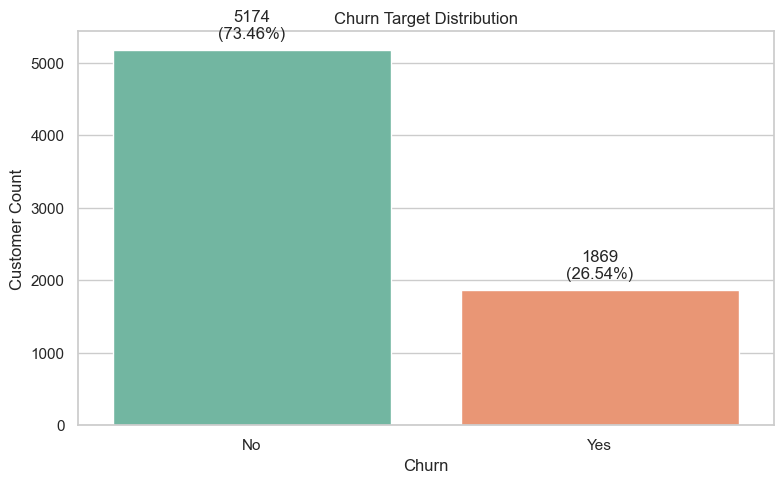

In [25]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_column, order=target_counts.index, palette="Set2")

for patch, label in zip(ax.patches, target_counts.index):
    count = int(target_counts[label])
    percentage = target_percentages[label]
    ax.annotate(
        f"{count}\n({percentage}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.set_title("Churn Target Distribution")
ax.set_xlabel(target_column)
ax.set_ylabel("Customer Count")
plt.tight_layout()
plt.show()


The target classes are moderately imbalanced. In this dataset, `No` is the majority class and `Yes` is the minority class, so downstream evaluation should rely on metrics beyond plain accuracy.


## Numerical Feature Analysis

Analyze each numerical feature on its own to understand central tendency, spread, skewness, and potential outliers.


In [26]:
numerical_summary = df[numerical_columns].describe().T
numerical_summary["median"] = df[numerical_columns].median()
numerical_summary["skew"] = df[numerical_columns].skew().round(2)
numerical_summary = numerical_summary[[
    "count",
    "mean",
    "median",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max",
    "skew",
]].round(2)

display(numerical_summary)


,count,mean,median,std,min,25%,50%,75%,max,skew
tenure,7043.0,32.37,29.00,24.56,0.00,9.00,29.00,55.00,72.00,0.24
MonthlyCharges,7043.0,64.76,70.35,30.09,18.25,35.50,70.35,89.85,118.75,-0.22
TotalCharges,7043.0,2279.73,1394.55,2266.79,0.00,398.55,1394.55,3786.60,8684.80,0.96


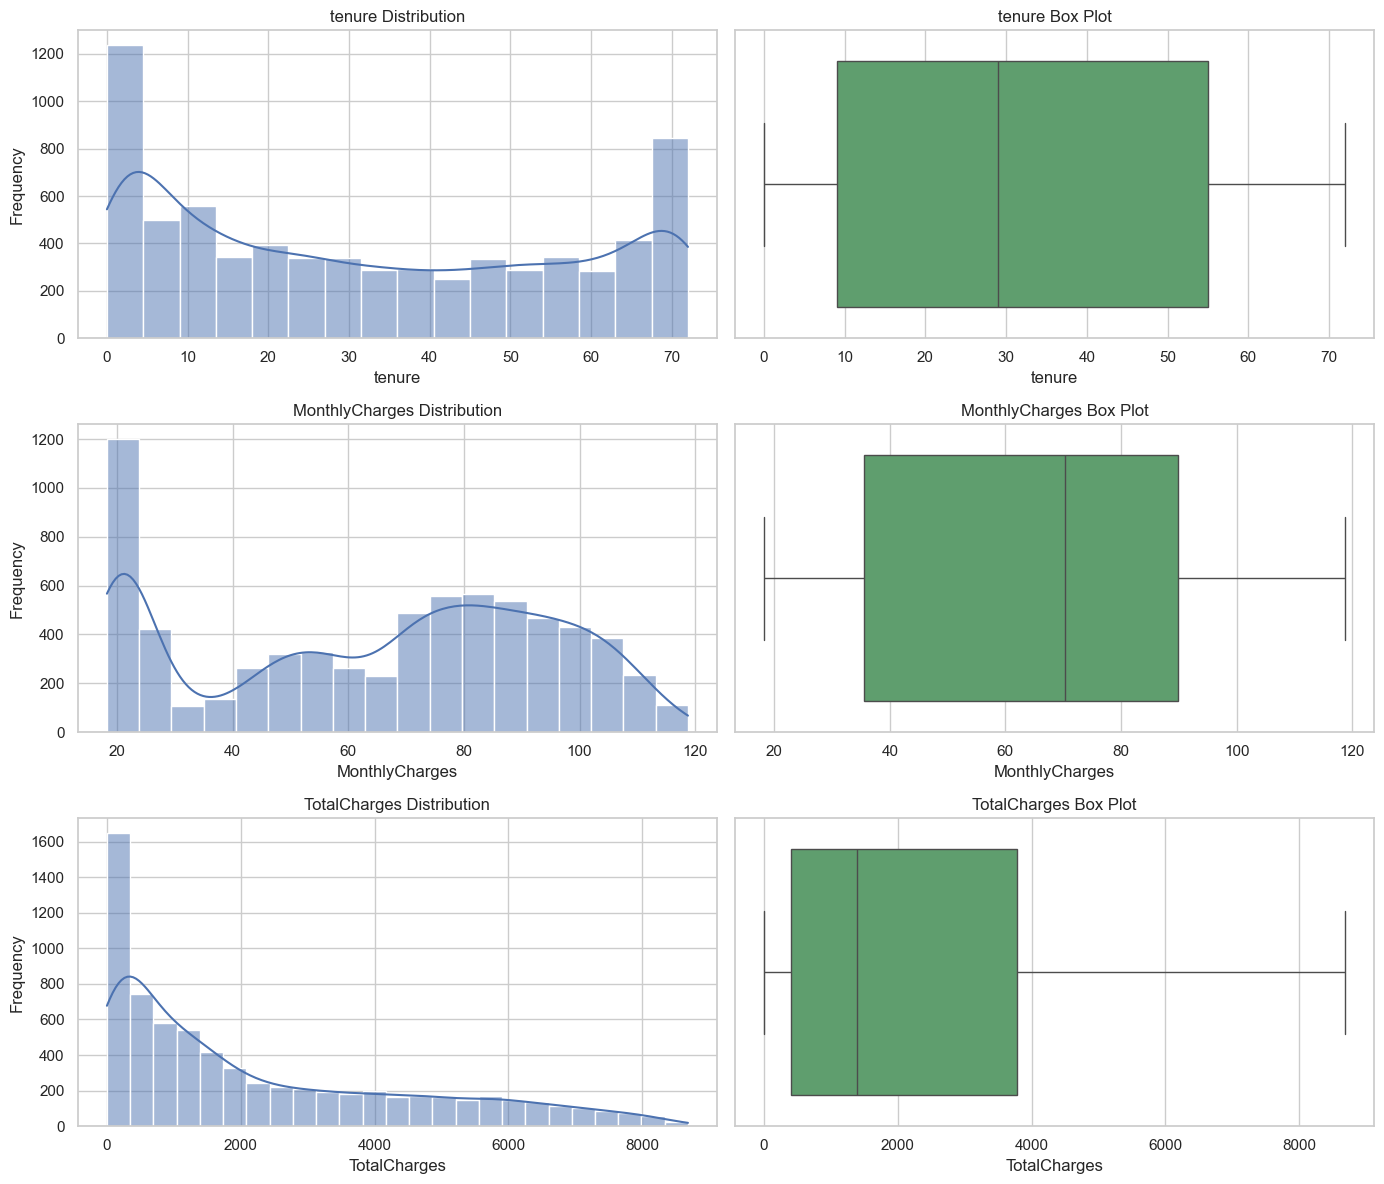

In [27]:
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(14, 4 * len(numerical_columns)))

if len(numerical_columns) == 1:
    axes = [axes]

for index, column in enumerate(numerical_columns):
    hist_ax, box_ax = axes[index]

    sns.histplot(data=df, x=column, kde=True, ax=hist_ax, color="#4C72B0")
    hist_ax.set_title(f"{column} Distribution")
    hist_ax.set_xlabel(column)
    hist_ax.set_ylabel("Frequency")

    sns.boxplot(data=df, x=column, ax=box_ax, color="#55A868")
    box_ax.set_title(f"{column} Box Plot")
    box_ax.set_xlabel(column)

plt.tight_layout()
plt.show()


In [28]:
outlier_summary = []

for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]

    outlier_summary.append({
        "feature": column,
        "q1": round(q1, 2),
        "q3": round(q3, 2),
        "iqr": round(iqr, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outlier_count,
    })

display(pd.DataFrame(outlier_summary))


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,tenure,9.00,55.00,46.00,-60.00,124.00,0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
2,TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0


The IQR-based outlier check shows that none of the numerical features falls outside the standard `1.5 x IQR` bounds, so there are no extreme outliers by this rule. `tenure` and `MonthlyCharges` are spread out but still well contained, while `TotalCharges` is more right-skewed without producing formal IQR outliers. This suggests that `TotalCharges` needs attention mainly for skewness and accumulation over time, not because of anomalous extreme points.

From the distribution plots, `tenure` and `MonthlyCharges` show low skew, while `TotalCharges` shows moderate right skew and should be watched more carefully. The box plots do not indicate visible extreme outliers under the IQR rule, and zeros are meaningful for features like `tenure` and `TotalCharges` because they can represent new customers with little or no service history.

Scaling may be useful later for distance-based or linear models because the numerical features are on different ranges, even when outliers are limited. A log transform is usually unnecessary for low-skew features, but it may help `TotalCharges` if you later use a model that is sensitive to skewed distributions.

Use the summary table, histograms, and box plots together. The table gives the main descriptive statistics, the histograms show distribution shape and skew, and the box plots plus IQR summary highlight potential outliers.


## Categorical Feature Analysis

For each categorical feature, review value counts, percentages, unique categories, rare categories, and whether any inconsistent labels still remain. Then use count plots or horizontal bar charts to identify dominant classes, imbalance, rare groups, and structural patterns such as `No internet service` or `No phone service`.


In [29]:
categorical_summaries = []

for column in categorical_columns:
    counts = df[column].value_counts(dropna=False)
    percentages = df[column].value_counts(dropna=False, normalize=True).mul(100).round(2)
    labels = df[column].dropna().astype(str)
    normalized_labels = labels.str.strip().str.lower()
    inconsistent_label_flag = normalized_labels.nunique() != labels.nunique()
    top_category = counts.index[0]
    top_percentage = percentages.iloc[0]
    rare_categories = int((percentages < 5).sum())

    if top_percentage >= 80:
        balance_note = "Highly imbalanced"
    elif top_percentage >= 60:
        balance_note = "Moderately imbalanced"
    else:
        balance_note = "Fairly distributed"

    categorical_summaries.append({
        "feature": column,
        "unique_categories": int(df[column].nunique(dropna=False)),
        "missing_count": int(df[column].isna().sum()),
        "top_category": top_category,
        "top_category_percentage": top_percentage,
        "rare_categories_lt_5pct": rare_categories,
        "inconsistent_labels": inconsistent_label_flag,
        "distribution_note": balance_note,
    })

categorical_summary_df = pd.DataFrame(categorical_summaries)
display(categorical_summary_df)


,feature,unique_categories,missing_count,top_category,top_category_percentage,rare_categories_lt_5pct,inconsistent_labels,distribution_note
0,gender,2,0,Male,50.48,0,False,Fairly distributed
1,SeniorCitizen,2,0,0,83.79,0,False,Highly imbalanced
2,Partner,2,0,No,51.70,0,False,Fairly distributed
3,Dependents,2,0,No,70.04,0,False,Moderately imbalanced
4,PhoneService,2,0,Yes,90.32,0,False,Highly imbalanced
5,MultipleLines,3,0,No,48.13,0,False,Fairly distributed
6,InternetService,3,0,Fiber optic,43.96,0,False,Fairly distributed
7,OnlineSecurity,3,0,No,49.67,0,False,Fairly distributed
8,OnlineBackup,3,0,No,43.84,0,False,Fairly distributed
9,DeviceProtection,3,0,No,43.94,0,False,Fairly distributed


In [30]:
for column in categorical_columns:
    category_table = pd.DataFrame({
        "count": df[column].value_counts(dropna=False),
        "percentage": df[column].value_counts(dropna=False, normalize=True).mul(100).round(2),
    })
    print(f"\nCategory distribution for {column}:")
    display(category_table)



Category distribution for gender:


,count,percentage
gender,,
Male,3555,50.48
Female,3488,49.52



Category distribution for SeniorCitizen:


,count,percentage
SeniorCitizen,,
0,5901,83.79
1,1142,16.21



Category distribution for Partner:


...

,count,percentage
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



Category distribution for PaperlessBilling:


,count,percentage
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



Category distribution for PaymentMethod:


,count,percentage
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_39113/2807216184.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=column, order=order, ax=ax, palette="Set2")
/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_39113/2807216184.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=column, order=order, ax=ax, palette="Set2")
/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_39113/2807216184.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=column, order=order, ax=ax, palette=

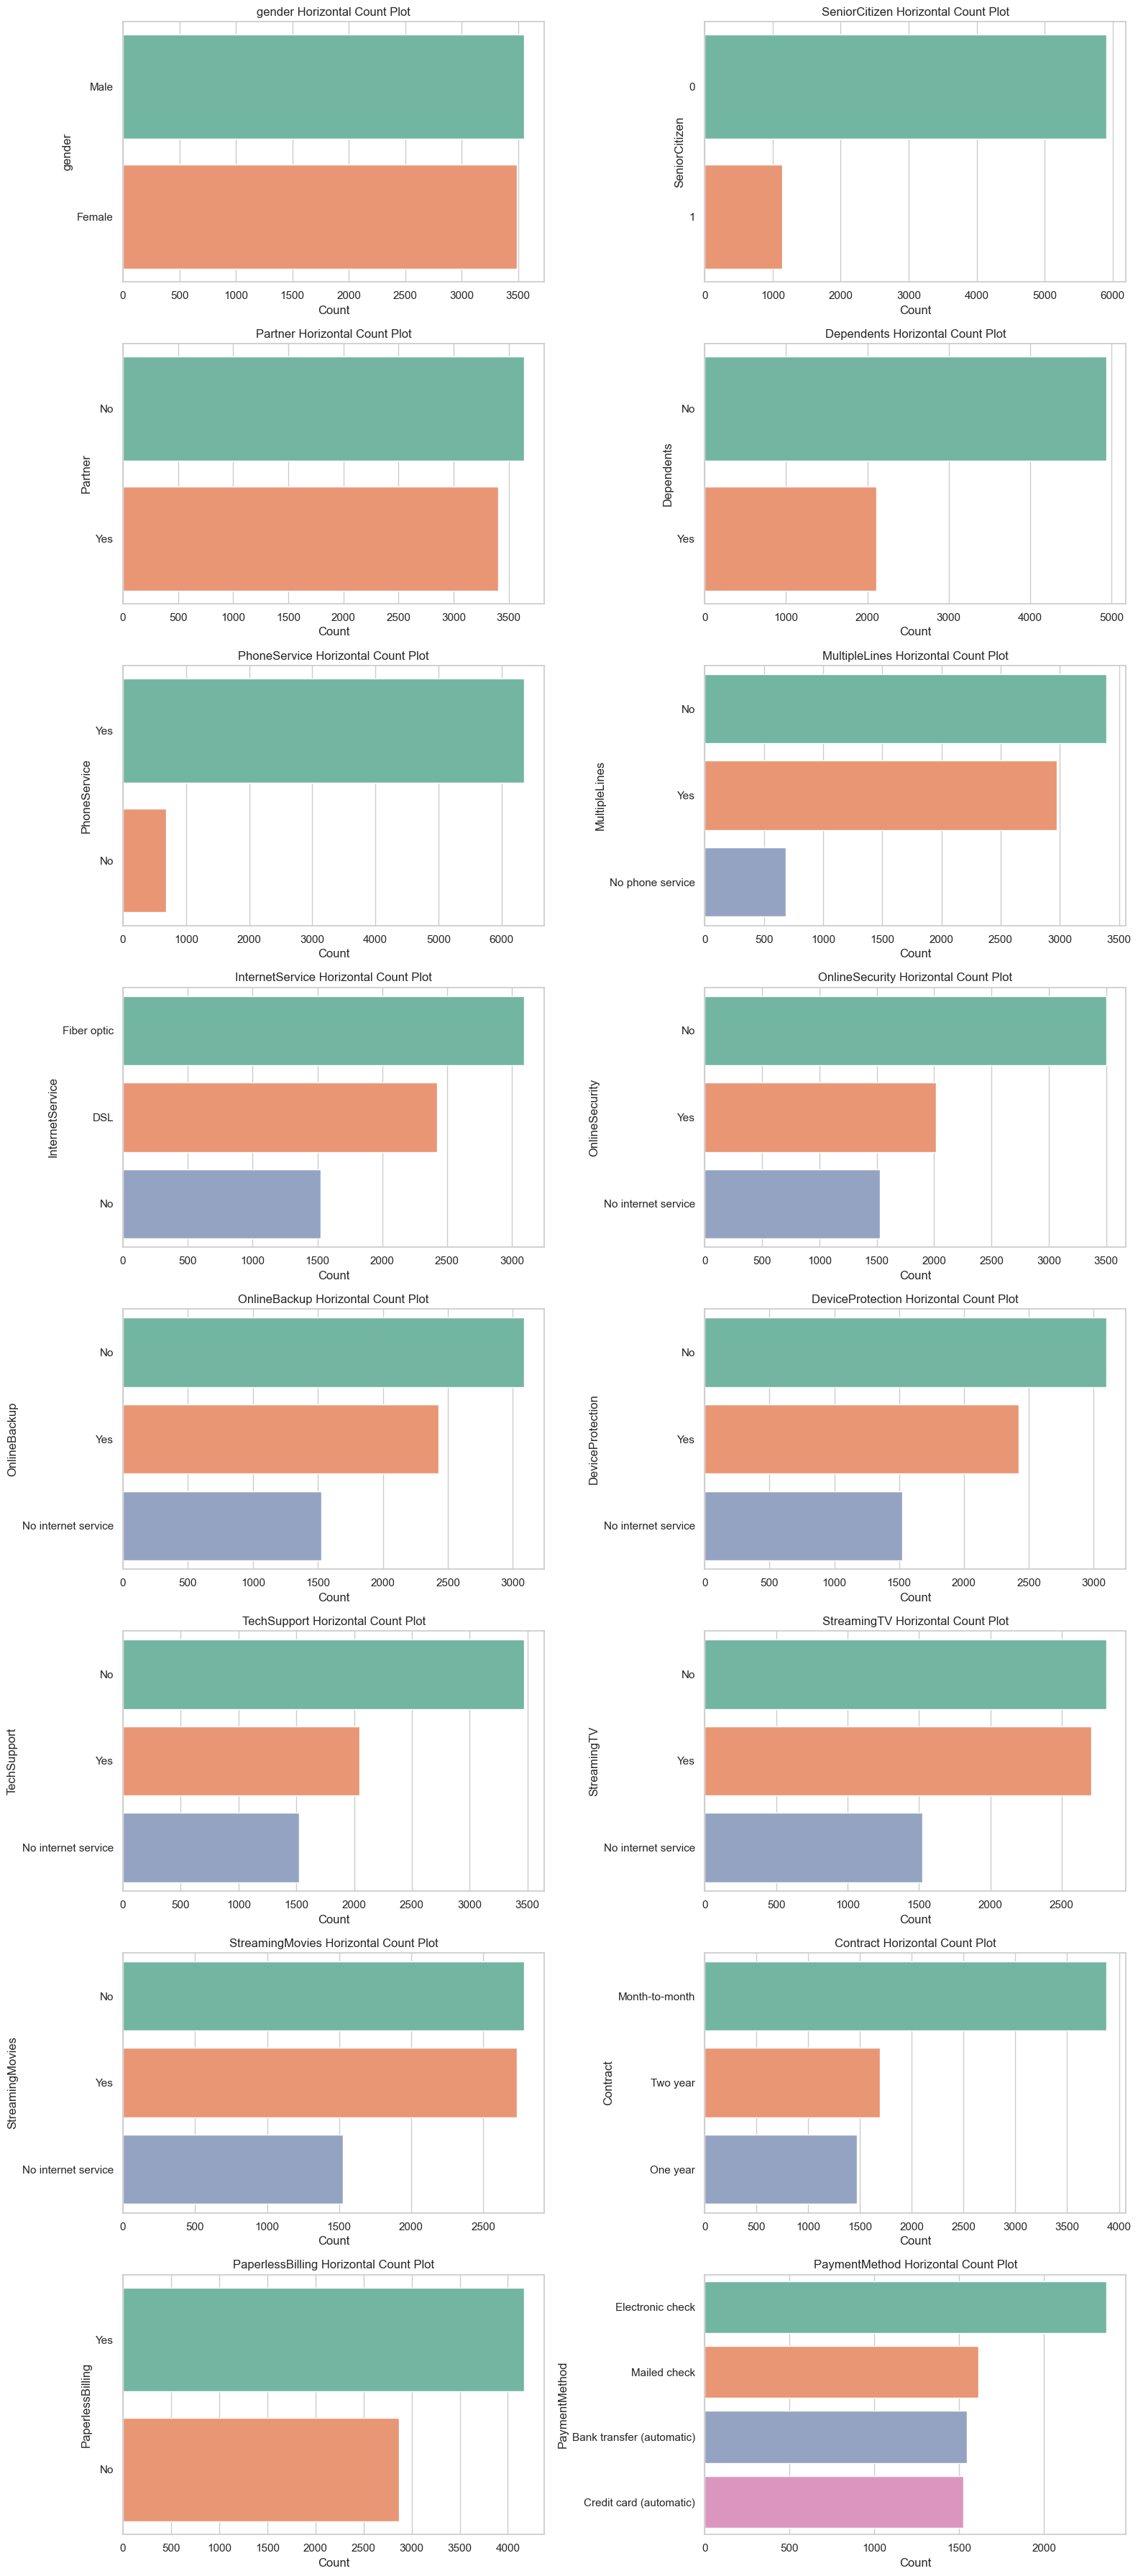

In [31]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for index, column in enumerate(categorical_columns):
    ax = axes[index]
    order = df[column].value_counts().index
    sns.countplot(data=df, y=column, order=order, ax=ax, palette="Set2")
    ax.set_title(f"{column} Horizontal Count Plot")
    ax.set_xlabel("Count")
    ax.set_ylabel(column)

for index in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[index])

plt.tight_layout()
plt.show()


Use the categorical summary table to review value counts, percentages, unique categories, rare levels, and any remaining inconsistent labels. The plots are drawn as horizontal count bars so categories stay readable, especially for columns with more levels such as `PaymentMethod`, and they help surface dominant classes, imbalance, and structural service-status values such as `No internet service` and `No phone service`.


### Categorical Findings

- Most categorical features do not contain rare levels below 5%, so category sparsity is not a major issue at this stage.
- Some binary features are clearly imbalanced, especially `PhoneService` and `SeniorCitizen`, while features such as `gender` and `Partner` are more evenly distributed.
- No obvious inconsistent labels remain after cleaning, which suggests category naming is already standardized across the dataset.
- Several service-related columns include structural categories like `No internet service` or `No phone service`, which are meaningful values rather than data-quality problems and should be preserved during encoding.
- `Contract`, `InternetService`, and `PaymentMethod` show useful multi-class variation, with `Month-to-month`, `Fiber optic`, and `Electronic check` being the most common categories in their respective features.


## Binary Column Analysis

Review the Yes/No type binary features separately because they are simple but important. For each one, check class counts, percentages, and whether the encoding is already normalized as clean `Yes` and `No` labels.


In [33]:
yes_no_columns = []
binary_summary_rows = []

for column in binary_columns:
    normalized_values = set(df[column].dropna().astype(str).str.strip().str.lower().unique())
    is_yes_no_normalized = normalized_values == {"yes", "no"}

    if normalized_values.issubset({"yes", "no"}):
        yes_no_columns.append(column)
        counts = df[column].value_counts(dropna=False)
        percentages = df[column].value_counts(dropna=False, normalize=True).mul(100).round(2)

        binary_summary_rows.append({
            "feature": column,
            "yes_count": int(counts.get("Yes", 0)),
            "no_count": int(counts.get("No", 0)),
            "yes_percentage": float(percentages.get("Yes", 0.0)),
            "no_percentage": float(percentages.get("No", 0.0)),
            "encoding_normalized": is_yes_no_normalized,
        })

binary_summary_df = pd.DataFrame(binary_summary_rows)
display(binary_summary_df)


,feature,yes_count,no_count,yes_percentage,no_percentage,encoding_normalized
0,Partner,3402,3641,48.30,51.70,True
1,Dependents,2110,4933,29.96,70.04,True
2,PhoneService,6361,682,90.32,9.68,True
3,PaperlessBilling,4171,2872,59.22,40.78,True


In [34]:
for column in yes_no_columns:
    binary_table = pd.DataFrame({
        "count": df[column].value_counts(dropna=False),
        "percentage": df[column].value_counts(dropna=False, normalize=True).mul(100).round(2),
    })
    print(f"\nYes/No distribution for {column}:")
    display(binary_table)



Yes/No distribution for Partner:


,count,percentage
Partner,,
No,3641,51.7
Yes,3402,48.3



Yes/No distribution for Dependents:


,count,percentage
Dependents,,
No,4933,70.04
Yes,2110,29.96



Yes/No distribution for PhoneService:


,count,percentage
PhoneService,,
Yes,6361,90.32
No,682,9.68



Yes/No distribution for PaperlessBilling:


,count,percentage
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78


The cleaned Yes/No features are already normalized, so they are ready for straightforward binary encoding later if needed. These columns are simple to interpret, but their class balance still matters because some features, such as `PhoneService`, are much more one-sided than others.
